In [1]:
import pandas as pd
import re

df = pd.read_csv("israeli_songs_corpus.csv")

def hebrew_words(text):
    return re.findall(r"[\u0590-\u05FF]+", str(text))

df["words"] = df["lyrics"].apply(hebrew_words)
df["word_count"] = df["words"].apply(len)
df["unique_word_count"] = df["words"].apply(lambda words: len(set(words)))

df["lexical_diversity"] = df["unique_word_count"] / df["word_count"]
df["lexical_diversity"] = df["lexical_diversity"].fillna(0)

df["line_count"] = df["lyrics"].apply(lambda x: len(str(x).splitlines()))

df["avg_line_length"] = df["word_count"] / df["line_count"]
df["avg_line_length"] = df["avg_line_length"].fillna(0)

summary = df.groupby("decade").agg(
    songs=("song_name", "count"),
    avg_words=("word_count", "mean"),
    median_words=("word_count", "median"),
    avg_unique_words=("unique_word_count", "mean"),
    avg_lexical_diversity=("lexical_diversity", "mean"),
    avg_lines=("line_count", "mean"),
    avg_line_length=("avg_line_length", "mean")
)

summary

,songs,avg_words,median_words,avg_unique_words,avg_lexical_diversity,avg_lines,avg_line_length
decade,,,,,,,
1980s,200,118.635000,110.0,75.840000,0.658962,28.46500,4.259601
2000s,200,129.050000,110.0,83.335000,0.663220,28.98500,4.514476
2020s,197,181.329949,162.0,96.878173,0.550848,40.22335,4.691257


In [6]:
import pandas as pd

df = pd.read_csv("israeli_songs_corpus.csv")

for decade in sorted(df["decade"].unique()):
    decade_df = df[df["decade"] == decade]

    decade_text = "\n\n".join(
        decade_df.apply(
            lambda row: f"### {row['song_name']} / {row['artist_name']}\n{row['lyrics']}",
            axis=1
        )
    )

    filename = f"dicta_all_{decade}.txt"

    with open(filename, "w", encoding="utf-8") as f:
        f.write(decade_text)

    print(filename, "songs:", len(decade_df), "characters:", len(decade_text))

dicta_all_1980s.txt songs: 200 characters: 130922
dicta_all_2000s.txt songs: 200 characters: 142337
dicta_all_2020s.txt songs: 197 characters: 193628


In [7]:
import os
import re
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF


Dataset shape: (597, 4)
                 song_name  artist_name decade  \
0  אני שומע שוב (שיר חייל)    שלמה ארצי  1980s   
1               דרך הכורכר    אריק סיני  1980s   
2        אני הולך לבית שאן  גרי אקשטיין  1980s   
3                    צוותא    שלמה ארצי  1980s   
4           אל תשכחי אותנו    מיסטר הרי  1980s   

                                              lyrics  
0  אני שומע שוב ברגעי השלווה\r\nאת ג'ניס ג'ופלין ...  
1  אני חוזר בדרך הכורכר\r\nבפיתולי אותו מסלול מוכ...  
2  אין חשמל ואין אפילו מים\r\nואין גם אף אחד שמתק...  
3  זה כבר כמה ימים\r\nשב"צוותא" מופיע זמר מחופש\r...  
4  אל תבקשי את כל אשר נתת\r\nלא אוכל להחזיר לך\r\...  

Columns: ['song_name', 'artist_name', 'decade', 'lyrics']

Songs per decade:
decade
1980s    200
2000s    200
2020s    197
Name: count, dtype: int64

Basic summary:


,decade,songs,avg_words,median_words,avg_unique_words,avg_lexical_diversity,avg_lines,avg_line_length,avg_repetition_ratio
0,1980s,200,118.635000,110.0,75.840000,0.658962,28.46500,4.259601,0.341038
1,2000s,200,129.050000,110.0,83.335000,0.663220,28.98500,4.514476,0.336780
2,2020s,197,181.329949,162.0,96.878173,0.550848,40.22335,4.691257,0.439000


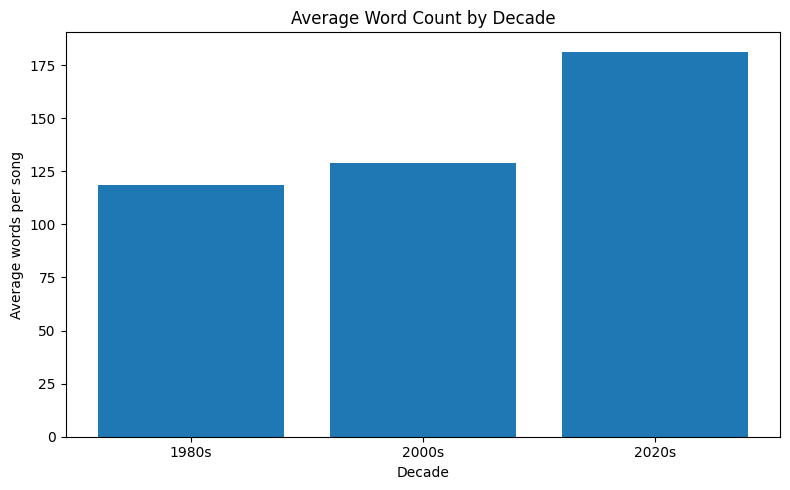

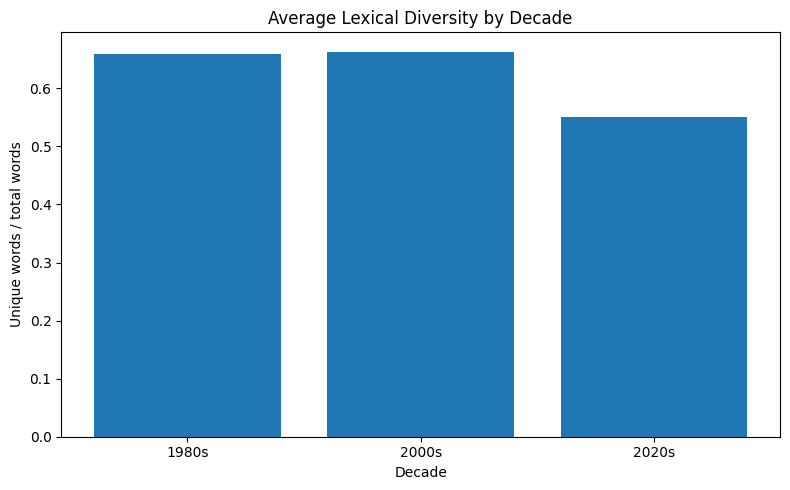

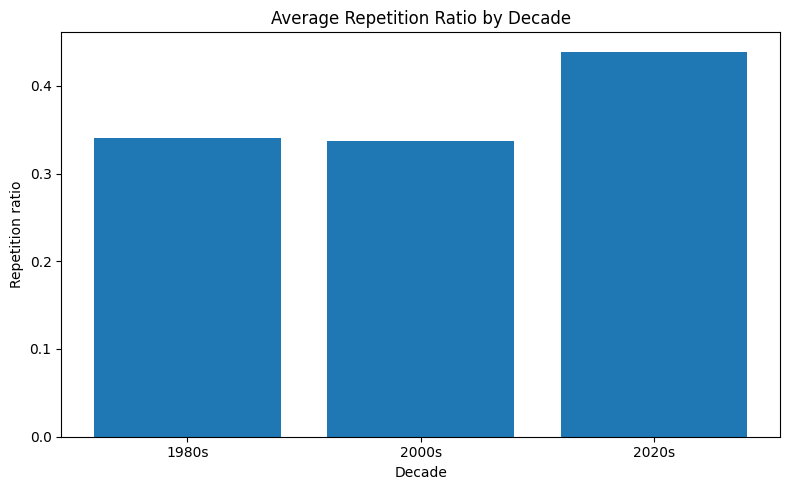


Dicta files found:
1980s ['dicta_all_1980s.ud.txt']
2000s ['dicta_all_2000s.ud.txt']
2020s ['dicta_all_2020s.ud.txt']

Dicta token counts by decade:
1980s 34094
2000s 36132
2020s 49255

Most common POS tags by decade:

 1980s
[('NOUN', 7425), ('ADP', 5717), ('VERB', 5113), ('PRON', 4123), ('DET', 3159), ('ADV', 2744), ('CCONJ', 1984), ('ADJ', 1472), ('PROPN', 790), ('SCONJ', 694), ('AUX', 357), ('NUM', 304), ('INTJ', 212)]

 2000s
[('NOUN', 6860), ('VERB', 6014), ('ADP', 5899), ('PRON', 4705), ('ADV', 3311), ('DET', 3023), ('CCONJ', 2023), ('ADJ', 1512), ('SCONJ', 1141), ('PROPN', 770), ('AUX', 440), ('NUM', 294), ('INTJ', 140)]

 2020s
[('NOUN', 8368), ('ADP', 8228), ('VERB', 8134), ('PRON', 7236), ('ADV', 4833), ('DET', 4019), ('CCONJ', 2305), ('ADJ', 1635), ('SCONJ', 1606), ('PROPN', 1384), ('AUX', 599), ('NUM', 534), ('INTJ', 371), ('', 3)]

POS summary:


,decade,token_count,NOUN_count,NOUN_ratio,VERB_count,VERB_ratio,ADJ_count,ADJ_ratio,ADV_count,ADV_ratio,...,SCONJ_count,SCONJ_ratio,NUM_count,NUM_ratio,AUX_count,AUX_ratio,INTJ_count,INTJ_ratio,PART_count,PART_ratio
0,1980s,34094,7425,0.217780,5113,0.149968,1472,0.043175,2744,0.080483,...,694,0.020355,304,0.008917,357,0.010471,212,0.006218,0,0.0
1,2000s,36132,6860,0.189859,6014,0.166445,1512,0.041847,3311,0.091636,...,1141,0.031579,294,0.008137,440,0.012178,140,0.003875,0,0.0
2,2020s,49255,8368,0.169891,8134,0.165141,1635,0.033195,4833,0.098122,...,1606,0.032606,534,0.010842,599,0.012161,371,0.007532,0,0.0


<Figure size 1400x700 with 0 Axes>

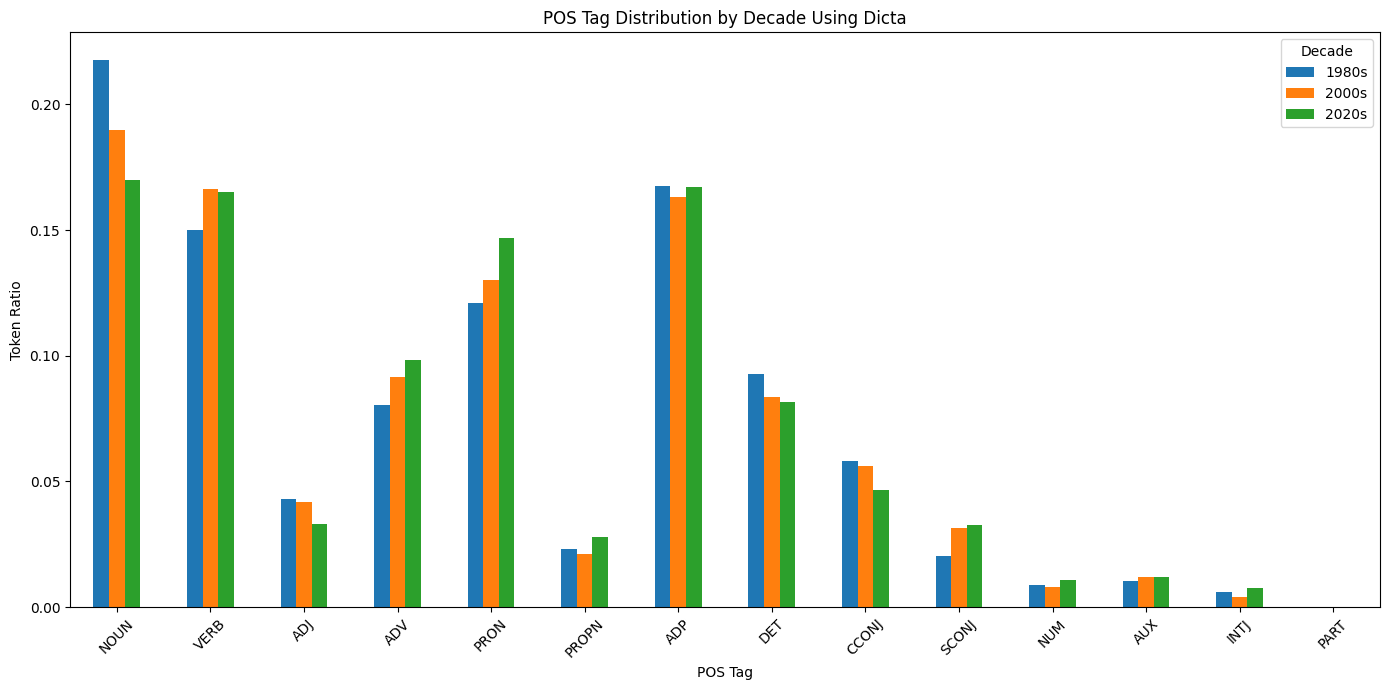


Top lemmas:


,decade,rank,lemma,count
0,1980s,1,כול,371
1,1980s,2,אל,300
2,1980s,3,בא,190
3,1980s,4,היי,188
4,1980s,5,אתה,182
5,1980s,6,יום,172
6,1980s,7,אני_,156
7,1980s,8,לילה,155
8,1980s,9,כבר,139
9,1980s,10,אמר,134



Top lemmas: 1980s
1. כול (371)
2. אל (300)
3. בא (190)
4. היי (188)
5. אתה (182)
6. יום (172)
7. אני_ (156)
8. לילה (155)
9. כבר (139)
10. אמר (134)
11. הלך (122)
12. רקד (118)
13. רצה (118)
14. אחד (108)
15. אנחנו (107)
16. שיר (105)
17. אולי (102)
18. בית (96)
19. לב (95)
20. דרך (92)

Top lemmas: 2000s
1. כול (434)
2. אתה (273)
3. בא (254)
4. אל (240)
5. היי (208)
6. אני_ (204)
7. יום (186)
8. ראה (172)
9. כש (146)
10. עכשיו (138)
11. כבר (136)
12. ידע (135)
13. רצה (133)
14. אתה_ (133)
15. הלך (127)
16. אחד (120)
17. אהבה (117)
18. אמר (116)
19. אולי (107)
20. טוב (107)

Top lemmas: 2020s
1. כול (795)
2. אתה (444)
3. אני_ (430)
4. בא (391)
5. היי (379)
6. אל (342)
7. יום (244)
8. אתה_ (229)
9. טוב (217)
10. עשה (199)
11. הגיד (194)
12. ראה (192)
13. רצה (189)
14. איך (188)
15. כבר (187)
16. ידע (176)
17. אנחנו (171)
18. לב (165)
19. הלך (155)
20. אחד (150)

Morphological features:


,decade,feature,count,ratio
0,1980s,Number=Sing,14847,0.192833
1,1980s,Gender=Masc,10582,0.137439
2,1980s,Gender=Fem,4997,0.064901
3,1980s,Voice=Act,4371,0.056771
4,1980s,HebBinyan=PAAL,3276,0.042549
5,1980s,PronType=Prs,3105,0.040328
6,1980s,Number=Plur,3089,0.040120
7,1980s,Person=3,2948,0.038289
8,1980s,PronType=Art,2629,0.034146
9,1980s,VerbForm=Part,2452,0.031847



Selected morphology summary:


,decade,Person=1_count,Person=1_ratio,Person=2_count,Person=2_ratio,Person=3_count,Person=3_ratio,Tense=Past_count,Tense=Past_ratio,Tense=Pres_count,...,Voice=Mid_count,Voice=Mid_ratio,Voice=Pass_count,Voice=Pass_ratio,VerbForm=Inf_count,VerbForm=Inf_ratio,VerbForm=Part_count,VerbForm=Part_ratio,Mood=Imp_count,Mood=Imp_ratio
0,1980s,2090,0.027145,1172,0.015222,2948,0.038289,1153,0.014975,0,...,356,0.004624,78,0.001013,567,0.007364,2452,0.031847,187,0.002429
1,2000s,2577,0.030923,1929,0.023148,2656,0.031871,1203,0.014436,0,...,403,0.004836,95,0.001140,878,0.010536,2524,0.030287,258,0.003096
2,2020s,4126,0.036054,3455,0.030190,3424,0.029919,1764,0.015414,0,...,457,0.003993,91,0.000795,1060,0.009262,3003,0.026241,327,0.002857


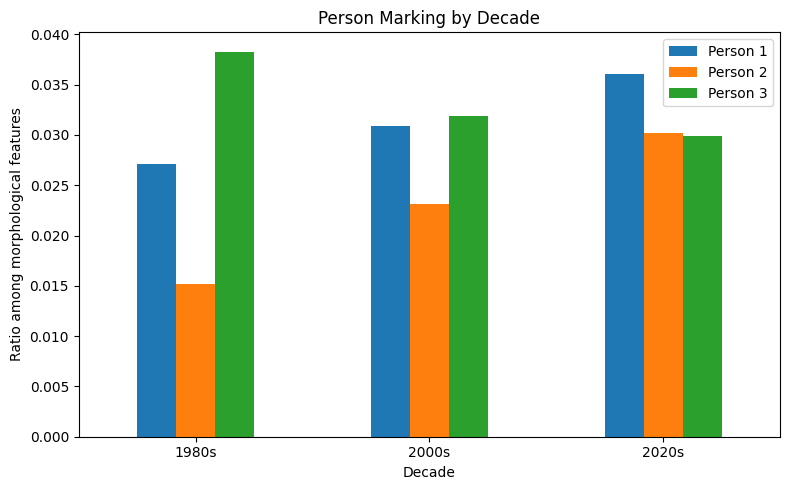

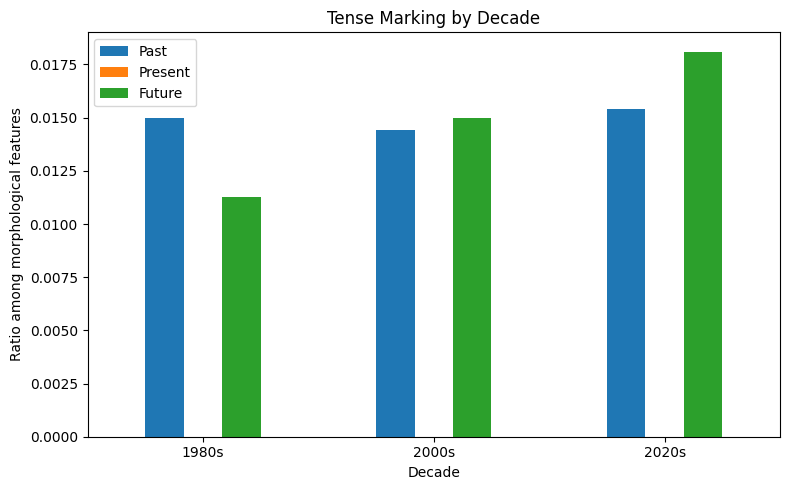


Binyan summary:


,decade,binyan,count,ratio
0,1980s,PAAL,3276,0.646281
1,1980s,PIEL,582,0.114816
2,1980s,HIFIL,507,0.100020
3,1980s,NIFAL,356,0.070231
4,1980s,HITPAEL,282,0.055632
5,1980s,PUAL,37,0.007299
6,1980s,HUFAL,29,0.005721
7,2000s,PAAL,3623,0.611580
8,2000s,HIFIL,726,0.122552
9,2000s,PIEL,712,0.120189


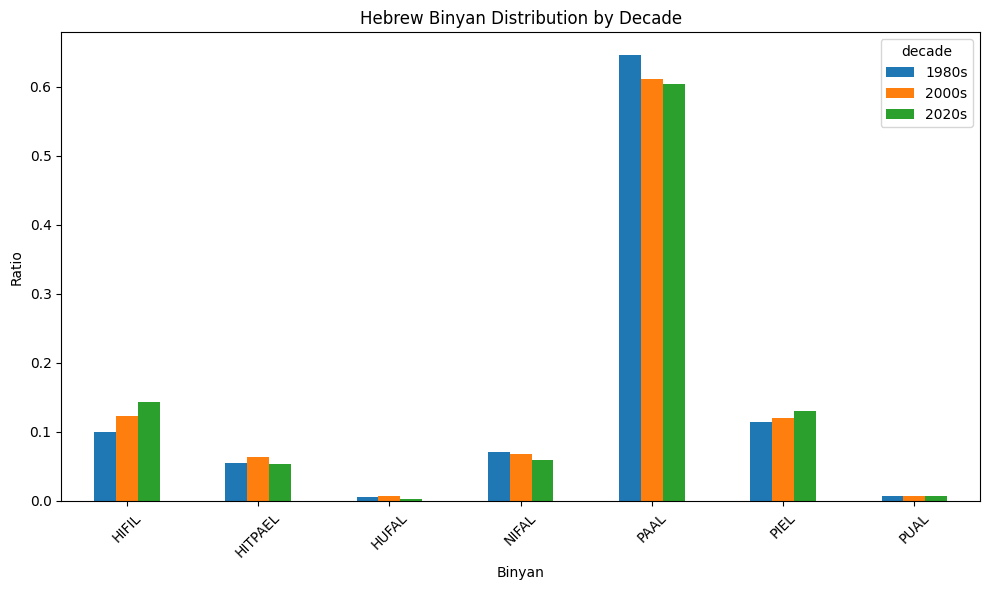


Top roots:


,decade,rank,root,count
0,1980s,1,בוא,198
1,1980s,2,אמר,134
2,1980s,3,הלך,126
3,1980s,4,רקד,119
4,1980s,5,רצי,118
5,1980s,6,ראי,110
6,1980s,7,נתן,87
7,1980s,8,ידע,83
8,1980s,9,עבר,81
9,1980s,10,חזר,72



Pronoun summary:


,decade,first_person_ratio,second_person_ratio,third_person_ratio
0,1980s,0.037630,0.031597,0.033507
1,2000s,0.047391,0.039616,0.022111
2,2020s,0.061022,0.054483,0.017288


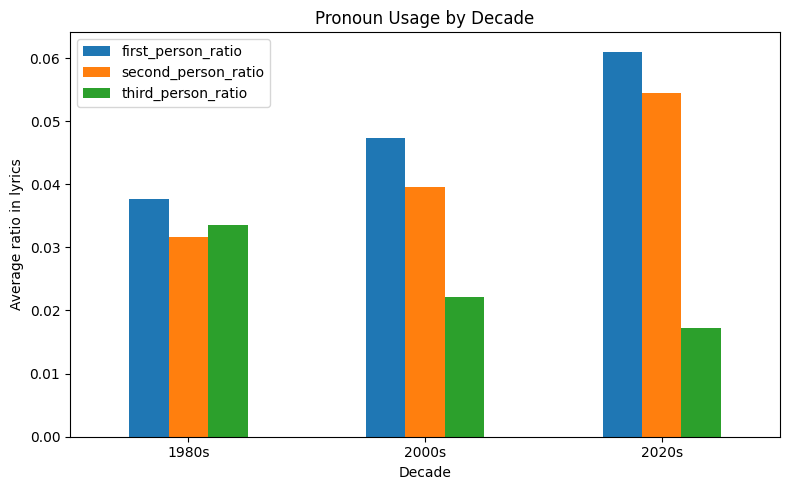


NMF Topics:

Topic 0:
אותך, תגידי, שלך, איך, ככה, איתך, שאת, כבר, כמה, ואת, שלא, הכל, למה, כשאת, אליי

Topic 1:
אתה, חצי, תגיד, שאתה, הי, ואתה, שלך, אותי, בי, שותה, אנ, עליך, כבר, תן, אליך

Topic 2:
הכל, אחד, הזמן, אחר, אולי, אף, כך, עד, ואני, לפעמים, אדם, הלילה, כולם, לבד, דבר

Topic 3:
אל, אותי, תשכחי, שוב, עלי, כבר, תמיד, הדרך, תעזבי, בי, העיר, נתתי, די, כך, מתהפך

Topic 4:
רוצה, יודע, אותי, הלילה, להיות, לעלות, שלה, בוא, מוניות, חם, ולעשות, חוויות, מילה, תפסיקי, מחפשת

Topic 5:
מאמץ, באפס, אה, קלאס, צריכה, פזמון, בית, שיגידו, שנמאס, תפחדי, לעבוד, ממש, יהיה, יה, קשה

Topic 6:
בא, הנה, בתוך, אה, עולה, איזה, אחד, יבוא, שר, האור, שכולם, באתי, תן, תרימו, למה

Topic 7:
שלי, זאת, יא, עושה, אלייך, בלב, אצלי, הייתי, אותי, איך, חביב, היית, אולי, אישה, הו

Topic distribution by decade:


main_topic,0,1,2,3,4,5,6,7
decade,,,,,,,,
1980s,0.045000,0.080000,0.455000,0.18000,0.105000,0.015000,0.070000,0.050000
2000s,0.105000,0.120000,0.435000,0.10000,0.075000,0.000000,0.080000,0.085000
2020s,0.253807,0.182741,0.192893,0.06599,0.060914,0.020305,0.096447,0.126904


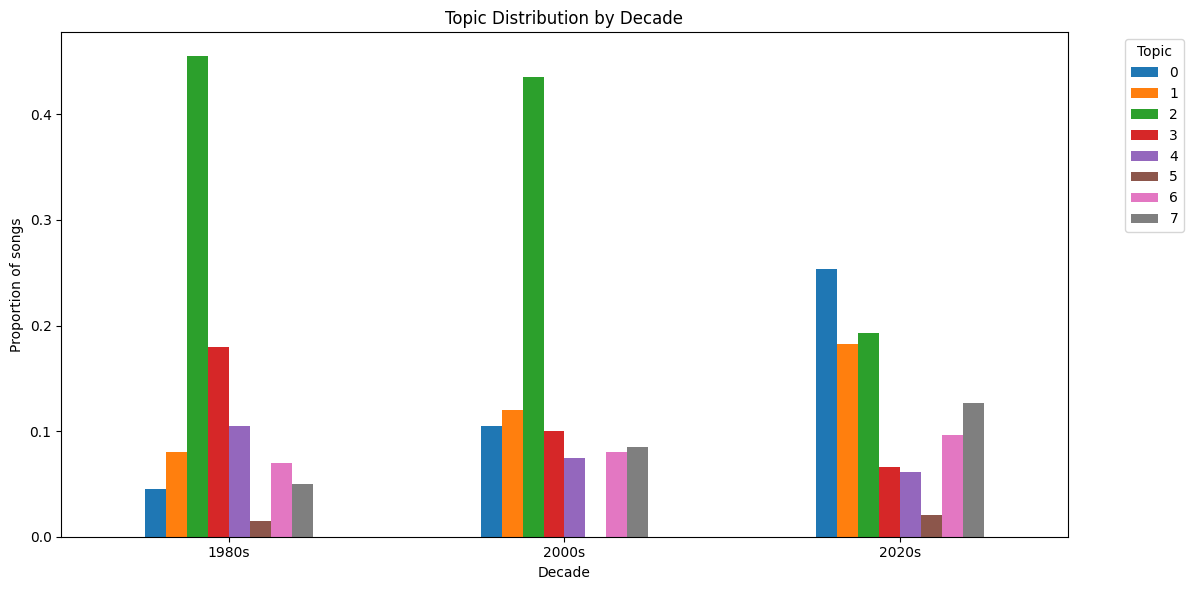


Example songs per topic:


,topic,song_name,artist_name,decade,topic_score
0,0,עוד אחד ששר לך,עילי בוטנר וגיא מזיג,2020s,0.201245
1,0,רוצה שלום,רביב כנר,2020s,0.200150
2,0,רק טוב,עילי בוטנר וילדי החוץ,2020s,0.163948
3,0,קרן שמש,בניה ברבי,2020s,0.159566
4,0,אין מאושר ממני,אליעד,2020s,0.157845
5,0,מקבל על עצמי,אושר כהן,2020s,0.157692
6,0,למה זה נגמר,דודו אהרון ועדן מאירי,2020s,0.157277
7,0,אקורדים בלילות,אושר כהן,2020s,0.152200
8,0,מסלוניקי עד ליפו,משה פרץ,2020s,0.146147
9,0,אהובי לב אדום,אושר כהן,2020s,0.145061



Saved all Stage 2 outputs successfully.

Final Stage 2 summary:


,decade,songs,avg_words,median_words,avg_unique_words,avg_lexical_diversity,avg_lines,avg_line_length,avg_repetition_ratio,first_person_ratio,second_person_ratio,third_person_ratio,NOUN_ratio,VERB_ratio,ADJ_ratio,ADV_ratio,PRON_ratio,PROPN_ratio
0,1980s,200,118.635000,110.0,75.840000,0.658962,28.46500,4.259601,0.341038,0.037630,0.031597,0.033507,0.217780,0.149968,0.043175,0.080483,0.120930,0.023171
1,2000s,200,129.050000,110.0,83.335000,0.663220,28.98500,4.514476,0.336780,0.047391,0.039616,0.022111,0.189859,0.166445,0.041847,0.091636,0.130217,0.021311
2,2020s,197,181.329949,162.0,96.878173,0.550848,40.22335,4.691257,0.439000,0.061022,0.054483,0.017288,0.169891,0.165141,0.033195,0.098122,0.146909,0.028099


In [9]:

# ============================================================
# 1. LOAD ORIGINAL CSV
# ============================================================

CSV_PATH = "israeli_songs_corpus.csv"

df = pd.read_csv(CSV_PATH)

print("Dataset shape:", df.shape)
print(df.head())
print("\nColumns:", df.columns.tolist())
print("\nSongs per decade:")
print(df["decade"].value_counts())


# ============================================================
# 2. BASIC HEBREW PREPROCESSING
# ============================================================

def hebrew_words(text):
    """
    Extract Hebrew words only.
    """
    return re.findall(r"[\u0590-\u05FF]+", str(text))


df["words"] = df["lyrics"].apply(hebrew_words)
df["word_count"] = df["words"].apply(len)
df["unique_word_count"] = df["words"].apply(lambda words: len(set(words)))

df["lexical_diversity"] = df["unique_word_count"] / df["word_count"]
df["lexical_diversity"] = df["lexical_diversity"].fillna(0)

df["line_count"] = df["lyrics"].apply(lambda x: len(str(x).splitlines()))
df["avg_line_length"] = df["word_count"] / df["line_count"]
df["avg_line_length"] = df["avg_line_length"].replace([np.inf, -np.inf], 0).fillna(0)

df["repetition_ratio"] = df["words"].apply(
    lambda words: 1 - len(set(words)) / len(words) if len(words) > 0 else 0
)


basic_summary = df.groupby("decade").agg(
    songs=("song_name", "count"),
    avg_words=("word_count", "mean"),
    median_words=("word_count", "median"),
    avg_unique_words=("unique_word_count", "mean"),
    avg_lexical_diversity=("lexical_diversity", "mean"),
    avg_lines=("line_count", "mean"),
    avg_line_length=("avg_line_length", "mean"),
    avg_repetition_ratio=("repetition_ratio", "mean")
).reset_index()

print("\nBasic summary:")
display(basic_summary)

basic_summary.to_csv(
    "stage2_basic_summary_by_decade.csv",
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 3. PLOT BASIC FEATURES
# ============================================================

def save_bar_plot(data, x_col, y_col, title, ylabel, filename):
    plt.figure(figsize=(8, 5))
    plt.bar(data[x_col], data[y_col])
    plt.title(title)
    plt.xlabel("Decade")
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()


save_bar_plot(
    basic_summary,
    "decade",
    "avg_words",
    "Average Word Count by Decade",
    "Average words per song",
    "plot_avg_word_count_by_decade.png"
)

save_bar_plot(
    basic_summary,
    "decade",
    "avg_lexical_diversity",
    "Average Lexical Diversity by Decade",
    "Unique words / total words",
    "plot_lexical_diversity_by_decade.png"
)

save_bar_plot(
    basic_summary,
    "decade",
    "avg_repetition_ratio",
    "Average Repetition Ratio by Decade",
    "Repetition ratio",
    "plot_repetition_ratio_by_decade.png"
)


# ============================================================
# 4. DICTA UD PARSER
# ============================================================

def parse_dicta_ud_file(path):
    """
    Parse Dicta .ud / .ud.txt file.

    Expected Dicta-style rows:
    ID    WORD    LEMMA    UPOS    XPOS    FEATS    ...

    This parser extracts:
    - POS counts
    - lemma counts
    - morphological feature counts
    - tense/person/gender/number counts
    - Hebrew binyan counts
    - Hebrew root counts

    It skips:
    - metadata lines beginning with #
    - multiword-token rows like 1-3
    - empty-node rows like 3.1
    - punctuation and unknown X rows
    """

    pos_counts = Counter()
    lemma_counts = Counter()
    morph_counts = Counter()
    token_counts = Counter()
    binyan_counts = Counter()
    root_counts = Counter()

    token_count = 0

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if not line:
                continue

            # Skip comments / sentence metadata
            if line.startswith("#"):
                continue

            parts = line.split("\t")

            if len(parts) < 4:
                continue

            token_id = parts[0]

            # Skip multiword-token rows like 1-6 and empty nodes like 3.1
            if "-" in token_id or "." in token_id:
                continue

            word = parts[1] if len(parts) > 1 else "_"
            lemma = parts[2] if len(parts) > 2 else "_"
            upos = parts[3] if len(parts) > 3 else "_"
            feats = parts[5] if len(parts) > 5 else "_"

            # Remove punctuation and unknown Dicta artifacts
            if upos in {"PUNCT", "X", "_"}:
                continue

            token_count += 1
            token_counts[word] += 1
            pos_counts[upos] += 1

            if lemma and lemma != "_":
                lemma_counts[lemma] += 1

            if feats and feats != "_":
                for feat in feats.split("|"):
                    if not feat:
                        continue

                    morph_counts[feat] += 1

                    if feat.startswith("HebBinyan="):
                        binyan_counts[feat.replace("HebBinyan=", "")] += 1

                    if feat.startswith("HebRoot="):
                        root_counts[feat.replace("HebRoot=", "")] += 1

    return {
        "file": path,
        "token_count": token_count,
        "pos_counts": pos_counts,
        "lemma_counts": lemma_counts,
        "morph_counts": morph_counts,
        "token_counts": token_counts,
        "binyan_counts": binyan_counts,
        "root_counts": root_counts
    }


# ============================================================
# 5. LOAD ALL DICTA FILES
# ============================================================

# Option A:
# If your files are exactly named like this, keep this dictionary.

dicta_files = {
    "1980s": ["dicta_all_1980s.ud.txt"],
    "2000s": ["dicta_all_2000s.ud.txt"],
    "2020s": ["dicta_all_2020s.ud.txt"]
}

# Option B:
# If your files have different names, comment Option A above and uncomment this:
#
# dicta_files = {
#     "1980s": sorted(glob.glob("*1980s*.ud*")),
#     "2000s": sorted(glob.glob("*2000s*.ud*")),
#     "2020s": sorted(glob.glob("*2020s*.ud*"))
# }


print("\nDicta files found:")
for decade, paths in dicta_files.items():
    print(decade, paths)


# Check files exist
for decade, paths in dicta_files.items():
    for path in paths:
        if not os.path.exists(path):
            print(f"WARNING: file not found: {path}")


# ============================================================
# 6. AGGREGATE DICTA RESULTS BY DECADE
# ============================================================

dicta_results = {}

for decade, paths in dicta_files.items():
    total_tokens = 0
    total_pos = Counter()
    total_lemmas = Counter()
    total_morph = Counter()
    total_token_counts = Counter()
    total_binyan = Counter()
    total_roots = Counter()

    for path in paths:
        parsed = parse_dicta_ud_file(path)

        total_tokens += parsed["token_count"]
        total_pos.update(parsed["pos_counts"])
        total_lemmas.update(parsed["lemma_counts"])
        total_morph.update(parsed["morph_counts"])
        total_token_counts.update(parsed["token_counts"])
        total_binyan.update(parsed["binyan_counts"])
        total_roots.update(parsed["root_counts"])

    dicta_results[decade] = {
        "token_count": total_tokens,
        "pos_counts": total_pos,
        "lemma_counts": total_lemmas,
        "morph_counts": total_morph,
        "token_counts": total_token_counts,
        "binyan_counts": total_binyan,
        "root_counts": total_roots
    }


print("\nDicta token counts by decade:")
for decade, data in dicta_results.items():
    print(decade, data["token_count"])

print("\nMost common POS tags by decade:")
for decade, data in dicta_results.items():
    print("\n", decade)
    print(data["pos_counts"].most_common())


# ============================================================
# 7. POS SUMMARY TABLE
# ============================================================

pos_tags = [
    "NOUN", "VERB", "ADJ", "ADV", "PRON",
    "PROPN", "ADP", "DET", "CCONJ", "SCONJ",
    "NUM", "AUX", "INTJ", "PART"
]

pos_rows = []

for decade, data in dicta_results.items():
    row = {
        "decade": decade,
        "token_count": data["token_count"]
    }

    for pos in pos_tags:
        count = data["pos_counts"].get(pos, 0)
        row[f"{pos}_count"] = count
        row[f"{pos}_ratio"] = count / data["token_count"] if data["token_count"] else 0

    pos_rows.append(row)


pos_df = pd.DataFrame(pos_rows)

print("\nPOS summary:")
display(pos_df)

pos_df.to_csv(
    "dicta_pos_summary_by_decade.csv",
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 8. POS RATIO PLOT
# ============================================================

ratio_cols = [f"{pos}_ratio" for pos in pos_tags if f"{pos}_ratio" in pos_df.columns]

plot_df = pos_df.set_index("decade")[ratio_cols].T
plot_df.index = [idx.replace("_ratio", "") for idx in plot_df.index]

plt.figure(figsize=(14, 7))
plot_df.plot(kind="bar", figsize=(14, 7))
plt.title("POS Tag Distribution by Decade Using Dicta")
plt.xlabel("POS Tag")
plt.ylabel("Token Ratio")
plt.xticks(rotation=45)
plt.legend(title="Decade")
plt.tight_layout()
plt.savefig("plot_dicta_pos_distribution_by_decade.png", dpi=300)
plt.show()


# ============================================================
# 9. TOP LEMMAS BY DECADE
# ============================================================

hebrew_stopwords = {
    "של", "את", "על", "עם", "אני", "זה", "לא", "כל", "מה", "מי",
    "לי", "לך", "לו", "לה", "לנו", "לכם", "לכן", "להם", "להן",
    "הוא", "היא", "הם", "הן", "כי", "גם", "אם", "יש", "אין", "עוד",
    "כמו", "אבל", "רק", "אז", "או", "יותר", "פה", "שם", "כאן",
    "ו", "ה", "ל", "ב", "מ", "ש", "כ", "_",
    "הזה", "הזאת", "אלה", "אלו", "אותו", "אותה", "אותם", "אותן"
}

lemma_rows = []

for decade, data in dicta_results.items():
    filtered_lemmas = [
        (lemma, count)
        for lemma, count in data["lemma_counts"].most_common(1000)
        if lemma not in hebrew_stopwords and len(lemma) > 1
    ]

    for rank, (lemma, count) in enumerate(filtered_lemmas[:50], start=1):
        lemma_rows.append({
            "decade": decade,
            "rank": rank,
            "lemma": lemma,
            "count": count
        })


lemma_df = pd.DataFrame(lemma_rows)

print("\nTop lemmas:")
display(lemma_df.head(30))

lemma_df.to_csv(
    "dicta_top_lemmas_by_decade.csv",
    index=False,
    encoding="utf-8-sig"
)


# Print top 20 lemmas per decade
for decade in sorted(dicta_results.keys()):
    print("\n" + "=" * 50)
    print("Top lemmas:", decade)
    print("=" * 50)

    temp = lemma_df[lemma_df["decade"] == decade].head(20)

    for _, row in temp.iterrows():
        print(f"{row['rank']}. {row['lemma']} ({row['count']})")


# ============================================================
# 10. MORPHOLOGICAL FEATURES TABLE
# ============================================================

morph_rows = []

for decade, data in dicta_results.items():
    total_morph = sum(data["morph_counts"].values())

    for feature, count in data["morph_counts"].most_common():
        morph_rows.append({
            "decade": decade,
            "feature": feature,
            "count": count,
            "ratio": count / total_morph if total_morph else 0
        })


morph_df = pd.DataFrame(morph_rows)

print("\nMorphological features:")
display(morph_df.head(40))

morph_df.to_csv(
    "dicta_morph_features_by_decade.csv",
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 11. SELECTED MORPHOLOGICAL FEATURES:
#     PERSON, TENSE, NUMBER, GENDER, VOICE
# ============================================================

interesting_features = [
    "Person=1", "Person=2", "Person=3",
    "Tense=Past", "Tense=Pres", "Tense=Fut",
    "Number=Sing", "Number=Plur", "Number=Dual",
    "Gender=Masc", "Gender=Fem",
    "Voice=Act", "Voice=Mid", "Voice=Pass",
    "VerbForm=Inf", "VerbForm=Part",
    "Mood=Imp"
]

selected_rows = []

for decade, data in dicta_results.items():
    total_morph = sum(data["morph_counts"].values())
    row = {"decade": decade}

    for feat in interesting_features:
        count = data["morph_counts"].get(feat, 0)
        row[f"{feat}_count"] = count
        row[f"{feat}_ratio"] = count / total_morph if total_morph else 0

    selected_rows.append(row)


selected_morph_df = pd.DataFrame(selected_rows)

print("\nSelected morphology summary:")
display(selected_morph_df)

selected_morph_df.to_csv(
    "dicta_selected_morphology_by_decade.csv",
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 12. PLOT PERSON FEATURES
# ============================================================

person_cols = ["Person=1_ratio", "Person=2_ratio", "Person=3_ratio"]

if all(col in selected_morph_df.columns for col in person_cols):
    person_plot = selected_morph_df.set_index("decade")[person_cols]
    person_plot.columns = ["Person 1", "Person 2", "Person 3"]

    person_plot.plot(kind="bar", figsize=(8, 5))
    plt.title("Person Marking by Decade")
    plt.xlabel("Decade")
    plt.ylabel("Ratio among morphological features")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig("plot_person_features_by_decade.png", dpi=300)
    plt.show()


# ============================================================
# 13. PLOT TENSE FEATURES
# ============================================================

tense_cols = ["Tense=Past_ratio", "Tense=Pres_ratio", "Tense=Fut_ratio"]

if all(col in selected_morph_df.columns for col in tense_cols):
    tense_plot = selected_morph_df.set_index("decade")[tense_cols]
    tense_plot.columns = ["Past", "Present", "Future"]

    tense_plot.plot(kind="bar", figsize=(8, 5))
    plt.title("Tense Marking by Decade")
    plt.xlabel("Decade")
    plt.ylabel("Ratio among morphological features")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig("plot_tense_features_by_decade.png", dpi=300)
    plt.show()


# ============================================================
# 14. HEBREW BINYAN SUMMARY
# ============================================================

binyan_rows = []

for decade, data in dicta_results.items():
    total_binyan = sum(data["binyan_counts"].values())

    for binyan, count in data["binyan_counts"].most_common():
        binyan_rows.append({
            "decade": decade,
            "binyan": binyan,
            "count": count,
            "ratio": count / total_binyan if total_binyan else 0
        })


binyan_df = pd.DataFrame(binyan_rows)

print("\nBinyan summary:")
display(binyan_df.head(30))

binyan_df.to_csv(
    "dicta_binyan_summary_by_decade.csv",
    index=False,
    encoding="utf-8-sig"
)


# Plot binyan distribution
if not binyan_df.empty:
    binyan_pivot = binyan_df.pivot_table(
        index="binyan",
        columns="decade",
        values="ratio",
        fill_value=0
    )

    binyan_pivot.plot(kind="bar", figsize=(10, 6))
    plt.title("Hebrew Binyan Distribution by Decade")
    plt.xlabel("Binyan")
    plt.ylabel("Ratio")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("plot_binyan_distribution_by_decade.png", dpi=300)
    plt.show()


# ============================================================
# 15. TOP HEBREW ROOTS BY DECADE
# ============================================================

root_rows = []

for decade, data in dicta_results.items():
    for rank, (root, count) in enumerate(data["root_counts"].most_common(50), start=1):
        root_rows.append({
            "decade": decade,
            "rank": rank,
            "root": root,
            "count": count
        })


root_df = pd.DataFrame(root_rows)

print("\nTop roots:")
display(root_df.head(30))

root_df.to_csv(
    "dicta_top_roots_by_decade.csv",
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 16. PRONOUN ANALYSIS FROM ORIGINAL LYRICS
#     Useful because songs often depend on I / you / he-she
# ============================================================

first_person = {
    "אני", "אנחנו", "לי", "לנו", "אותי", "אותנו",
    "שלי", "שלנו", "בי", "בנו", "אליי", "אלינו"
}

second_person = {
    "אתה", "את", "אתם", "אתן",
    "לך", "לכם", "לכן",
    "אותך", "אתכם", "אתכן",
    "שלך", "שלכם", "שלכן",
    "בך", "בכם", "בכן",
    "אליך", "אלייך", "אליכם", "אליכן"
}

third_person = {
    "הוא", "היא", "הם", "הן",
    "לו", "לה", "להם", "להן",
    "אותו", "אותה", "אותם", "אותן",
    "שלו", "שלה", "שלהם", "שלהן",
    "בו", "בה", "בהם", "בהן"
}

def count_group(words, group):
    return sum(1 for w in words if w in group)


df["first_person_count"] = df["words"].apply(lambda words: count_group(words, first_person))
df["second_person_count"] = df["words"].apply(lambda words: count_group(words, second_person))
df["third_person_count"] = df["words"].apply(lambda words: count_group(words, third_person))

df["first_person_ratio"] = df["first_person_count"] / df["word_count"]
df["second_person_ratio"] = df["second_person_count"] / df["word_count"]
df["third_person_ratio"] = df["third_person_count"] / df["word_count"]

df[["first_person_ratio", "second_person_ratio", "third_person_ratio"]] = df[
    ["first_person_ratio", "second_person_ratio", "third_person_ratio"]
].replace([np.inf, -np.inf], 0).fillna(0)

pronoun_summary = df.groupby("decade")[
    ["first_person_ratio", "second_person_ratio", "third_person_ratio"]
].mean().reset_index()

print("\nPronoun summary:")
display(pronoun_summary)

pronoun_summary.to_csv(
    "pronoun_summary_by_decade.csv",
    index=False,
    encoding="utf-8-sig"
)

pronoun_plot = pronoun_summary.set_index("decade")
pronoun_plot.plot(kind="bar", figsize=(8, 5))
plt.title("Pronoun Usage by Decade")
plt.xlabel("Decade")
plt.ylabel("Average ratio in lyrics")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("plot_pronoun_usage_by_decade.png", dpi=300)
plt.show()


# ============================================================
# 17. TOPIC MODELING: TF-IDF + NMF
# ============================================================

topic_stopwords = hebrew_stopwords.union({
    "כן", "שם", "פה", "עכשיו", "היום", "מחר", "פעם",
    "דרך", "זמן", "יום", "לילה", "לב", "חיים"
})

def clean_hebrew_text_for_topics(text):
    words = hebrew_words(text)
    words = [
        w for w in words
        if w not in topic_stopwords and len(w) > 1
    ]
    return " ".join(words)


df["clean_lyrics_for_topics"] = df["lyrics"].apply(clean_hebrew_text_for_topics)

vectorizer = TfidfVectorizer(
    token_pattern=r"[\u0590-\u05FF]+",
    max_features=3000,
    min_df=3,
    max_df=0.75
)

X = vectorizer.fit_transform(df["clean_lyrics_for_topics"])

NUM_TOPICS = 8

nmf = NMF(
    n_components=NUM_TOPICS,
    random_state=42,
    init="nndsvda",
    max_iter=1000
)

topic_matrix = nmf.fit_transform(X)
terms = vectorizer.get_feature_names_out()

topic_rows = []

print("\nNMF Topics:")
for topic_idx, topic in enumerate(nmf.components_):
    top_indices = topic.argsort()[-15:][::-1]
    top_terms = [terms[i] for i in top_indices]

    print(f"\nTopic {topic_idx}:")
    print(", ".join(top_terms))

    for rank, term in enumerate(top_terms, start=1):
        topic_rows.append({
            "topic": topic_idx,
            "rank": rank,
            "term": term,
            "weight": topic[top_indices[rank - 1]]
        })


topic_terms_df = pd.DataFrame(topic_rows)

topic_terms_df.to_csv(
    "topic_modeling_nmf_top_terms.csv",
    index=False,
    encoding="utf-8-sig"
)

df["main_topic"] = topic_matrix.argmax(axis=1)
df["main_topic_score"] = topic_matrix.max(axis=1)


# ============================================================
# 18. TOPIC DISTRIBUTION BY DECADE
# ============================================================

topic_distribution = pd.crosstab(
    df["decade"],
    df["main_topic"],
    normalize="index"
)

print("\nTopic distribution by decade:")
display(topic_distribution)

topic_distribution.to_csv(
    "topic_distribution_by_decade.csv",
    encoding="utf-8-sig"
)

topic_distribution.plot(kind="bar", figsize=(12, 6))
plt.title("Topic Distribution by Decade")
plt.xlabel("Decade")
plt.ylabel("Proportion of songs")
plt.xticks(rotation=0)
plt.legend(title="Topic", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("plot_topic_distribution_by_decade.png", dpi=300)
plt.show()


# ============================================================
# 19. EXAMPLE SONGS PER TOPIC
# ============================================================

example_rows = []

for topic in sorted(df["main_topic"].unique()):
    topic_df = df[df["main_topic"] == topic].sort_values(
        "main_topic_score",
        ascending=False
    ).head(10)

    for _, row in topic_df.iterrows():
        example_rows.append({
            "topic": topic,
            "song_name": row["song_name"],
            "artist_name": row["artist_name"],
            "decade": row["decade"],
            "topic_score": row["main_topic_score"]
        })

topic_examples_df = pd.DataFrame(example_rows)

print("\nExample songs per topic:")
display(topic_examples_df.head(30))

topic_examples_df.to_csv(
    "topic_examples_top_songs.csv",
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 20. SAVE ENRICHED DATASET
# ============================================================

df.to_csv(
    "israeli_songs_stage2_enriched.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved all Stage 2 outputs successfully.")


# ============================================================
# 21. OPTIONAL: CREATE A COMPACT FINAL STAGE 2 SUMMARY
# ============================================================

final_summary = basic_summary.merge(
    pronoun_summary,
    on="decade",
    how="left"
)

# Add selected POS ratios
selected_pos_for_summary = [
    "NOUN_ratio", "VERB_ratio", "ADJ_ratio", "ADV_ratio",
    "PRON_ratio", "PROPN_ratio"
]

pos_small = pos_df[["decade"] + selected_pos_for_summary].copy()

final_summary = final_summary.merge(
    pos_small,
    on="decade",
    how="left"
)

final_summary.to_csv(
    "stage2_final_summary_table.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nFinal Stage 2 summary:")
display(final_summary)

In [10]:
from google.colab import files
import glob

output_files = glob.glob("*.csv") + glob.glob("*.png")

for file in output_files:
    files.download(file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>